In [ ]:
# import all the libary 
import torch as tr
import os
from torchvision import datasets, transforms,models
from torch.utils.data import random_split, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from collections import Counter
from PIL import Image
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
# Defined the device need 
device = tr.device("cuda" if tr.cuda.is_available() else "cpu")
print(device)


if not tr.cuda.is_available():
    raise RuntimeError("CUDA GPU not found!")

device = tr.device("cuda")

cuda


In [3]:
# create a transfromer for image dataset
# ── Training transform (with augmentation) ──────────────────
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── Testing transform (NO augmentation) ─────────────────────
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
# use transform_train for dataset_train only
# keep original transform for dataset_test

In [ ]:

# ── Load SAME folder TWICE with different transforms ──
full_train = datasets.ImageFolder(
    root=r"C:\Users\LOQ\OneDrive\Desktop\deep leaning cnn\deep leaning cnn\train",
    transform=transform_train
)
full_test = datasets.ImageFolder(
    root=r"C:\Users\LOQ\OneDrive\Desktop\deep leaning cnn\deep leaning cnn\train",
    transform=transform_test
)

# ── Stratified Split ──
labels = [label for _, label in full_train.samples]

train_idx, test_idx = train_test_split(
    range(len(labels)),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_dataset = Subset(full_train, train_idx)
test_dataset  = Subset(full_test,  test_idx)

# ── Verify Balance ──
train_labels = [labels[i] for i in train_idx]
test_labels  = [labels[i] for i in test_idx]
print("Train:", Counter(train_labels))
print("Test :", Counter(test_labels))

# ── DataLoaders ──
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

Train: Counter({1: 2081, 0: 1663})
Test : Counter({1: 520, 0: 416})


In [5]:
#transfrom the data in to gpu 
for images, labels in train_loader:

    # ← data is on CPU here
    images = images.to(device)   # move to CUDA ✅
    labels = labels.to(device)   # move to CUDA ✅

    # ← now data is on GPU, ready for CNN

In [6]:
class cat_dog_classifation(nn.Module):
    
    def __init__(self,num_class:int = 10 ):
        super().__init__()
        
        self.block1 = nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),
            nn.Dropout2d(p=0.2)
            
        )
        
        
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # [B, 64, 16, 16]
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),  # [B, 64, 16, 16]
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                           # [B, 64,  8,  8]
            nn.Dropout2d(p=0.25),
        )
        
        
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # [B,128,  8,  8]
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                           # [B,128,  4,  4]
            nn.Dropout2d(p=0.25),
        )
        self.block4 = nn.Sequential(
          nn.Conv2d(128, 256, kernel_size=3, padding=1),
          nn.BatchNorm2d(256),
          nn.ReLU(inplace=True),
          nn.MaxPool2d(2, 2),
          nn.Dropout2d(0.25)
        )   
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1,1))
        
        self.classifier = nn.Linear(256,num_class)
        
        
    def forward(self, x):
            x = self.block1(x)           # [B,  32, 16, 16]
            x = self.block2(x)           # [B,  64,  8,  8]
            x = self.block3(x)           # [B, 128,  4,  4]
            x = self.block4(x)
            x = self.global_avg_pool(x)  # [B, 128,  1,  1]
            x = x.view(x.size(0), -1)    # [B, 128]
            x = self.classifier(x)       # [B,  10]
            return x

In [7]:
model = cat_dog_classifation(num_class=2).to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.0001, weight_decay=1e-4)
epoch = 50

cat_dog_classifation(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, 

In [8]:
model.train()
for i in range(epoch):
    for batch_features, batch_labels in train_loader:
        image = batch_features.to(device)
        labels = batch_labels.to(device)
        output = model(image)
        loss = criterion(output,labels)
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{i+1}/{epoch}], Loss: {loss.item():.4f}")

Epoch [1/50], Loss: 0.6670
Epoch [2/50], Loss: 0.7069
Epoch [3/50], Loss: 0.7434
Epoch [4/50], Loss: 0.5576
Epoch [5/50], Loss: 0.6603
Epoch [6/50], Loss: 0.6689
Epoch [7/50], Loss: 0.6408
Epoch [8/50], Loss: 0.5743
Epoch [9/50], Loss: 0.6700
Epoch [10/50], Loss: 0.5829
Epoch [11/50], Loss: 0.6702
Epoch [12/50], Loss: 0.6693
Epoch [13/50], Loss: 0.5956
Epoch [14/50], Loss: 0.7515
Epoch [15/50], Loss: 0.7356
Epoch [16/50], Loss: 0.5769
Epoch [17/50], Loss: 0.5374
Epoch [18/50], Loss: 0.7256
Epoch [19/50], Loss: 0.5695
Epoch [20/50], Loss: 0.7045
Epoch [21/50], Loss: 0.6739
Epoch [22/50], Loss: 0.6076
Epoch [23/50], Loss: 0.5960
Epoch [24/50], Loss: 0.6541
Epoch [25/50], Loss: 0.6157
Epoch [26/50], Loss: 0.6893
Epoch [27/50], Loss: 0.7106
Epoch [28/50], Loss: 0.6030
Epoch [29/50], Loss: 0.5481
Epoch [30/50], Loss: 0.5953
Epoch [31/50], Loss: 0.5689
Epoch [32/50], Loss: 0.5673
Epoch [33/50], Loss: 0.5686
Epoch [34/50], Loss: 0.4865
Epoch [35/50], Loss: 0.6015
Epoch [36/50], Loss: 0.6510
E

In [ ]:
# pre-train model used 

model = models.mobilenet_v2(pretrained=True)

# ── Freeze all layers first ──
for param in model.parameters():
    param.requires_grad = False

# ── Unfreeze last 7 layers for better dog features ──
for param in model.features[-7:].parameters():
    param.requires_grad = True

# ── Replace classifier ──
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.last_channel, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 2)
)

model = model.to(device)
print(model)

# ── Loss, Optimizer, Scheduler ──
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ── Training Loop ──
epoch = 50
best_accuracy = 0.0

for i in range(epoch):
    model.train()
    running_loss = 0.0

    for batch_features, batch_labels in train_loader:
        images = batch_features.to(device)
        labels = batch_labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        print(f"epoch{i+1}/{epoch} loss items{running_loss}")

    avg_loss = running_loss / len(train_loader)
    scheduler.step(avg_loss)


c:\Users\LOQ\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\LOQ\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
# model is eval to find the 
model.eval()
test_loss, correct, total = 0.0, 0, 0
 
with tr.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        test_loss += criterion(outputs, labels).item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        avg_loss = test_loss / len(test_loader)
        accuracy = 100. * correct / total

print(f"Test Loss: {avg_loss:.4f}")
print(f"Test Accuracy: {accuracy:.2f}%")

Test Loss: 0.0613
Test Accuracy: 98.08%


In [26]:
model.eval()

correct = 0
total = 0

with tr.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = tr.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

train_accuracy = 100 * correct / total

print("Train Accuracy:", train_accuracy)

Train Accuracy: 99.9732905982906


In [ ]:
image = Image.open(
    r"C:\Users\LOQ\OneDrive\Desktop\deep leaning cnn\deep leaning cnn\train\images (1).jpg"
).convert("RGB")

# ── Must use transform_test NOT transform_train ──
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

image = transform(image)
image = image.unsqueeze(0).to(device)

model.eval()
with tr.no_grad():
    output = model(image)
    
    # ── See actual confidence scores ──
    probs = tr.softmax(output, dim=1)
    print(f"Cat confidence: {probs[0][0]*100:.2f}%")
    print(f"Dog confidence: {probs[0][1]*100:.2f}%")
    
    pred = output.argmax(dim=1).item()

classes = ["cat", "dog"]
print("Prediction:", classes[pred])

Cat confidence: 50.37%
Dog confidence: 49.63%
Prediction: cat


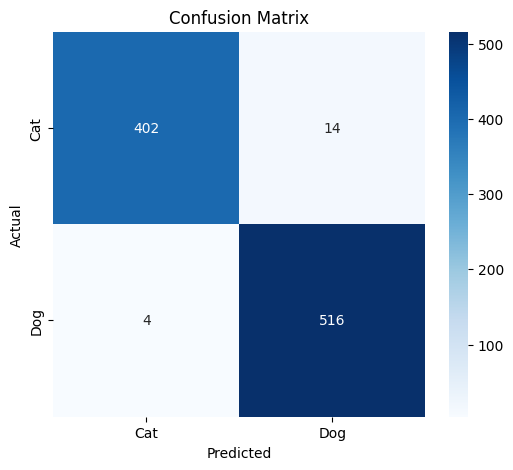

In [ ]:

import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Cat', 'Dog'],
    yticklabels=['Cat', 'Dog']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
# ── Save after training ──
tr.save(model.state_dict(), "cat_dog_model.pth")
print("Model Saved!")

# ── Load it back later ──
model = cat_dog_classifation(num_class=2).to(device)
model.load_state_dict(tr.load("cat_dog_model.pth"))
model.eval()
print("Model Loaded!")

Model Saved!
Model Loaded!
